# 读取SMPS数据文件，绘制时间序列图

version: 1.0

## 读取单个文件

注意: 在读取函数写出来后处于废弃状态

In [ ]:
# 处理单个SMPS导出的数据文件，读取并打印自检信息(在读取函数写出来后处于废弃状态)
import numpy as np
import pandas as pd
import pathlib

file_path = pathlib.Path(r"D:\Coding\Data\Lanzhou_aerosol\S82\logDp\20241205-20251215(dNdlogDp).TXT")

df = pd.read_csv(file_path, sep="\t", encoding="cp1252", skiprows=25)

t = pd.to_datetime(df['Date']+' '+df['Start Time'], format='%Y/%m/%d %H:%M:%S')
df["__dt__"] = t
df = df.sort_values("__dt__").reset_index(drop=True)
t = df["__dt__"]

BIN_COLS = list(df.columns[9:112])

Dp = np.array(BIN_COLS).astype(float)# unit: nm

# 保留特定时间段的数据
start_time = pd.to_datetime("2024-12-06 00:00:00")
end_time = pd.to_datetime("2024-12-15 00:00:00")
mask = (t >= start_time) & (t <= end_time)
df = df.loc[mask].reset_index(drop=True)
t = t.loc[mask].reset_index(drop=True)

dN = df[BIN_COLS].apply(pd.to_numeric).to_numpy().T

dt_diff = pd.Series(t).diff().dropna() # 计算时间间隔

print("时间点数 =", len(t))
print("粒径bin数 =", len(Dp))
print("Dp范围(µm) =", np.nanmin(Dp), "~", np.nanmax(Dp))
print("采样间隔(秒)：中位数 =", dt_diff.dt.total_seconds().median(),
      "，最小 =", dt_diff.dt.total_seconds().min(),
      "，最大 =", dt_diff.dt.total_seconds().max())
print("dN(or dN/dlogDp)统计(#/cm3)：min =", np.nanmin(dN), "max =", np.nanmax(dN))
print("dN(or dN/dlogDp)为0或缺测的比例 =", np.mean((dN <= 0) | np.isnan(dN)))
print("log10(dN or dN/dlogDp)最大值（忽略<=0）≈", np.nanmax(np.log10(np.where(dN>0, dN, np.nan))))
print("数据变量到底是dN还是dN/dlogDp，需要参考数据文件(txt文件前几行)确认")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from matplotlib.ticker import FixedLocator, NullLocator

# --- 0) 准备：确保 t 是 datetime，Dp 是 float array，dN 是 (bin, time) ---
# t: pandas Series of datetime
# Dp: numpy array (len=bin)
# dN: numpy array shape = (bin, time)

# 1) 计算 x 轴边界（pcolormesh 需要 edges）
t_num = mdates.date2num(pd.to_datetime(t).to_numpy())
dt = np.median(np.diff(t_num))
x_edges = np.r_[t_num[0] - 0.5*dt,
                0.5*(t_num[:-1] + t_num[1:]),
                t_num[-1] + 0.5*dt]

# 2) 计算 y 轴边界（用相邻几何平均值当 bin 边界；首尾做外推）
y_edges = np.empty(len(Dp)+1)
y_edges[1:-1] = np.sqrt(Dp[:-1] * Dp[1:])
y_edges[0] = Dp[0]**2 / y_edges[1]
y_edges[-1] = Dp[-1]**2 / y_edges[-2]

print(len(x_edges), len(y_edges), dN.shape[1]+1, dN.shape[0]+1)  # 检查维度是否匹配

# 3) 颜色：线性 dN（<0 设为 NaN，用于显示缺测/无效）
Z = np.where(dN >= 0, dN, np.nan)

# 4) 作图
fig, ax = plt.subplots(figsize=(12, 3.5), dpi=160)

cmap = plt.colormaps["jet"].copy()
cmap.set_bad("white")

vmin = 0
vmax = np.nanpercentile(Z, 99.5)
Z = np.ma.masked_invalid(Z) # 这一行需要放在 vmax (分位数)计算之后
pcm = ax.pcolormesh(x_edges, y_edges, Z, shading="auto",
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax
                    )

ax.set_yscale("log")
ax.set_ylabel("Electrical mobility diameter (nm)")
ax.set_xlabel("Date")

# y 刻度
yticks = [13.6, 40, 100, 200, 300, 532.8]
ax.yaxis.set_major_locator(FixedLocator(yticks))
ax.yaxis.set_minor_locator(NullLocator())
ax.yaxis.set_major_formatter(lambda v, pos: f"{v:g}")
ax.set_ylim(y_edges[0], y_edges[-1])

# x 轴按天显示
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%y/%m/%d"))
fig.autofmt_xdate()# 自动旋转日期标签

# colorbar
cbar = fig.colorbar(pcm, ax=ax, pad=0.01)
cbar.set_label("SMPS $dN/dlog D_p$ (# $cm^{-3}$)", rotation=270, labelpad=15)
#cbar.set_ticks([0, 0.5, 1, 1.5, 2, 2.5])

plt.tight_layout()
plt.show()

## 读取多个文件

In [1]:
# 1. 导入库, 定义读取函数
from pathlib import Path
import pandas as pd
import numpy as np

def read_one_smps_export(path: Path, encoding="cp1252", bin_start_idx=9, bin_end_idx=112, time_format='%Y/%m/%d %H:%M:%S', scan_lines=100) -> pd.DataFrame:
    # 1) 定位表头行 (只扫描前`scan_lines`行)
    with open(path, "r", encoding=encoding, errors="replace") as f:
        lines = []
        for _ in range(scan_lines):
            try:
                lines.append(next(f))
            except StopIteration:
                break

    header_idx = None
    for i, line in enumerate(lines):
        if 'Units' in line:
            units_idx = i
        if "Sample #" in line and "Date" in line and "Start Time" in line:
            if line.count("\t") >= 5 or line.count(",") >= 5 or line.count(";") >= 5:
                header_idx = i
                break
    if header_idx is None:
        raise ValueError(f"{path.name}: 扫描前`scan_lines`行, 未找到表头行")
    
    header_line = lines[header_idx]
    #print(f"{path.name}的数据类型： {lines[units_idx].split('\t')[1]} ")
    if lines[units_idx].split('\t')[1].strip() != "dw/dlogDp":
        raise ValueError(f"{path.name}: 数据类型不是 dN/dlogDp，而是 {lines[units_idx].split('\t')[1]}")

    # 2) 识别分隔符
    delims = {"\t": header_line.count("\t"), ",": header_line.count(","), ";": header_line.count(";")}
    sep = max(delims, key=delims.get)

    # 3) 从表头行开始读
    df = pd.read_csv(path, sep=sep, encoding=encoding, skiprows=0, header=header_idx, engine="python")

    # 4) 生成 datetime
    t = pd.to_datetime(df["Date"].astype(str).str.strip() + " " + df["Start Time"].astype(str).str.strip(),
                       errors="coerce", # 如果需要更严格的解析, 可以去掉此行
                       format=time_format)
    bad = t.isna()
    if bad.any():
        print("解析失败行数:", bad.sum())
        print("如果行数较多，可能需要调整 time_format 参数")
        print(df.loc[bad, ["Date", "Start Time"]].head(10))
        # 需要的话：raise ValueError("Datetime parsing failed")

    df = df.loc[t.notna()].copy()
    df["__dt__"] = t.loc[t.notna()].values

    # 5) 粒径列
    BIN_COLS = list(df.columns[bin_start_idx:bin_end_idx])
    # 判断粒径列是否正确选取
    try:
        _ = np.array(BIN_COLS).astype(float)
    except ValueError:
        raise ValueError(f"{path.name}: 粒径列名不能转换为浮点数，可能选取错误：{BIN_COLS[:5]}...\n请尝试调整 bin_start_idx 和 bin_end_idx 参数")

    out = df[["__dt__"] + BIN_COLS].copy()
    out["__file__"] = path.name  # 便于追踪来源
    return out

In [2]:
# 2. 读取并合并多个 TXT 数据文件

data_dir = Path(r"D:\Coding\Data\Lanzhou_aerosol\SMPS_dNdlogDp")
txt_files = list(data_dir.glob('*.TXT'))# 获取所有 TXT 文件
print("TXT 文件数 =", len(txt_files))

all_parts = []
for p in txt_files:
    try:
        one = read_one_smps_export(p)
        all_parts.append(one)
        print(f"✅ {p.name}: {len(one)} 行, 时间 {one['__dt__'].min()} ~ {one['__dt__'].max()}")
    except Exception as e:
        print(f"❌ {p.name}: 读取失败 -> {repr(e)}")

merged = pd.concat(all_parts, ignore_index=True)
merged = merged.sort_values("__dt__").reset_index(drop=True)

n_before = len(merged)
n_dups = merged.duplicated(subset="__dt__").sum()

# 去重策略：同一时间点保留“最后出现的那条”（通常后导出的文件更完整）
merged = merged.drop_duplicates(subset="__dt__", keep="last").reset_index(drop=True)

print("\n=== 合并结果 ===")
print("合并前总行数 =", n_before)
print("重复时间点数 =", int(n_dups))
print("去重后总行数 =", len(merged))
print("总时间范围 =", merged["__dt__"].min(), "~", merged["__dt__"].max())

# 采样间隔检查
dt_diff = merged["__dt__"].diff().dropna().dt.total_seconds()
print("采样间隔(秒)：中位数 =", float(dt_diff.median()),
      "最小 =", float(dt_diff.min()),
      "最大 =", float(dt_diff.max()))

TXT 文件数 = 33
✅ 20241205-1215.TXT: 7440 行, 时间 2024-12-05 13:17:56 ~ 2024-12-15 21:15:55
✅ 20241215-1229.TXT: 10093 行, 时间 2024-12-15 21:19:58 ~ 2024-12-29 21:43:57
✅ 20241230.TXT: 115 行, 时间 2024-12-30 18:38:48 ~ 2024-12-30 22:26:47
✅ 20241231-20250105.TXT: 3793 行, 时间 2024-12-31 11:02:24 ~ 2025-01-05 17:26:23
✅ 20250105-0119.TXT: 2550 行, 时间 2025-01-16 00:01:07 ~ 2025-01-19 12:59:07
✅ 20250119.TXT: 243 行, 时间 2025-01-19 14:22:57 ~ 2025-01-19 22:26:56
✅ 20250120-0128.TXT: 5737 行, 时间 2025-01-20 19:20:42 ~ 2025-01-28 18:32:41
✅ 20250204-0206.TXT: 1694 行, 时间 2025-02-04 15:32:45 ~ 2025-02-06 23:58:44
✅ 20250210-0211.TXT: 807 行, 时间 2025-02-10 12:21:16 ~ 2025-02-11 15:13:15
✅ 20250211-0212.TXT: 931 行, 时间 2025-02-11 15:26:52 ~ 2025-02-12 22:26:51
✅ 20250215-0217.TXT: 1530 行, 时间 2025-02-15 12:19:53 ~ 2025-02-17 15:17:52
✅ 20250218-0219.TXT: 687 行, 时间 2025-02-18 12:24:20 ~ 2025-02-19 11:16:19
✅ 20250219-0221.TXT: 1774 行, 时间 2025-02-19 11:22:07 ~ 2025-02-21 22:28:06
✅ 20250222-0224.TXT: 1516 行, 时间 202

In [3]:
# 3. 对齐到规则时间网格
import numpy as np
import pandas as pd

BIN_COLS = []
for col in merged.columns:
    try:
        float(col)
        BIN_COLS.append(col)
    except ValueError:
        continue

merged = merged.sort_values("__dt__").reset_index(drop=True)

# 使用采样间隔中位数作为网格步长
dt_sec = dt_diff.median()

# 选一个“网格原点”（用最早时间的秒级，避免小数）
origin = merged["__dt__"].min().floor("s")

# 计算每条记录距离 origin 的秒数，并四舍五入到最近的格点
sec = (merged["__dt__"] - origin).dt.total_seconds().to_numpy()
k = np.round(sec / dt_sec).astype(int)   # 贴到最近格点
merged["__dt_grid__"] = origin + pd.to_timedelta(k * dt_sec, unit="s")

# ===== 剔除异常高浓度时间段（按对齐后的网格时间 __dt_grid__ 删除）=====
bad_periods = [
    ("2024-12-14 23:00", "2024-12-16 00:00"),
    ("2024-12-22 19:00", "2024-12-23 12:00"),
    ("2025-03-10 04:00", "2025-03-10 14:00"),
    ("2025-03-25 21:00", "2025-03-25 23:00"),
    ("2025-05-30 15:10", "2025-05-30 15:15"),# 扫描不完全导致浓度异常低, 详情见SMPS原始数据文件
    ("2025-06-19 00:00", "2025-06-20 00:00"),
    ("2025-07-23 14:50", "2025-07-23 15:00"),
    ("2025-08-11 17:49", "2025-08-11 17:50"),
    ("2025-08-14 23:00", "2025-08-15 16:00"),
    ("2025-10-16 23:00", "2025-10-19 00:00"),
]
bad_periods = [(pd.Timestamp(s), pd.Timestamp(e)) for s, e in bad_periods]

mask_bad = np.zeros(len(merged), dtype=bool)
for s, e in bad_periods:
    m1 = merged["__dt_grid__"].between(s, e, inclusive="both")
    print(f"剔除区间 {s} ~ {e}: {int(m1.sum())} 行")
    mask_bad |= m1

print("总剔除行数 =", int(mask_bad.sum()))
merged = merged.loc[~mask_bad].reset_index(drop=True)
# ============================================================


# 如果因为抖动导致多个样本落在同一个格点：用 mean 或 last 聚合
# 查看有多少样本因为抖动导致落在同一个格点
print("落在同一个格点的样本数分布:")
print(merged.groupby("__dt_grid__").size().describe())

# mean 更平滑；last 更接近“保留最后一次记录”
grid_df = (merged.groupby("__dt_grid__")[BIN_COLS]
                 .mean()
                 .sort_index())

# 生成完整规则网格并 reindex (缺测点用 NaN)
t_grid = pd.date_range(start=grid_df.index.min(), end=grid_df.index.max(), freq=f"{dt_sec}s")
m = grid_df.reindex(t_grid)

print("原始点数 =", len(merged))
print("对齐后唯一格点数 =", len(grid_df))
print("规则网格点数 =", len(t_grid))
print("缺测格点数 =", int(m.isna().all(axis=1).sum()))


剔除区间 2024-12-14 23:00:00 ~ 2024-12-16 00:00:00: 749 行
剔除区间 2024-12-22 19:00:00 ~ 2024-12-23 12:00:00: 510 行
剔除区间 2025-03-10 04:00:00 ~ 2025-03-10 14:00:00: 300 行
剔除区间 2025-03-25 21:00:00 ~ 2025-03-25 23:00:00: 52 行
剔除区间 2025-05-30 15:10:00 ~ 2025-05-30 15:15:00: 2 行
剔除区间 2025-06-19 00:00:00 ~ 2025-06-20 00:00:00: 100 行
剔除区间 2025-07-23 14:50:00 ~ 2025-07-23 15:00:00: 5 行
剔除区间 2025-08-11 17:49:00 ~ 2025-08-11 17:50:00: 1 行
剔除区间 2025-08-14 23:00:00 ~ 2025-08-15 16:00:00: 510 行
剔除区间 2025-10-16 23:00:00 ~ 2025-10-19 00:00:00: 1183 行
总剔除行数 = 3412
落在同一个格点的样本数分布:
count    182607.000000
mean          1.000646
std           0.025412
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           2.000000
dtype: float64
原始点数 = 182725
对齐后唯一格点数 = 182607
规则网格点数 = 227092
缺测格点数 = 44485


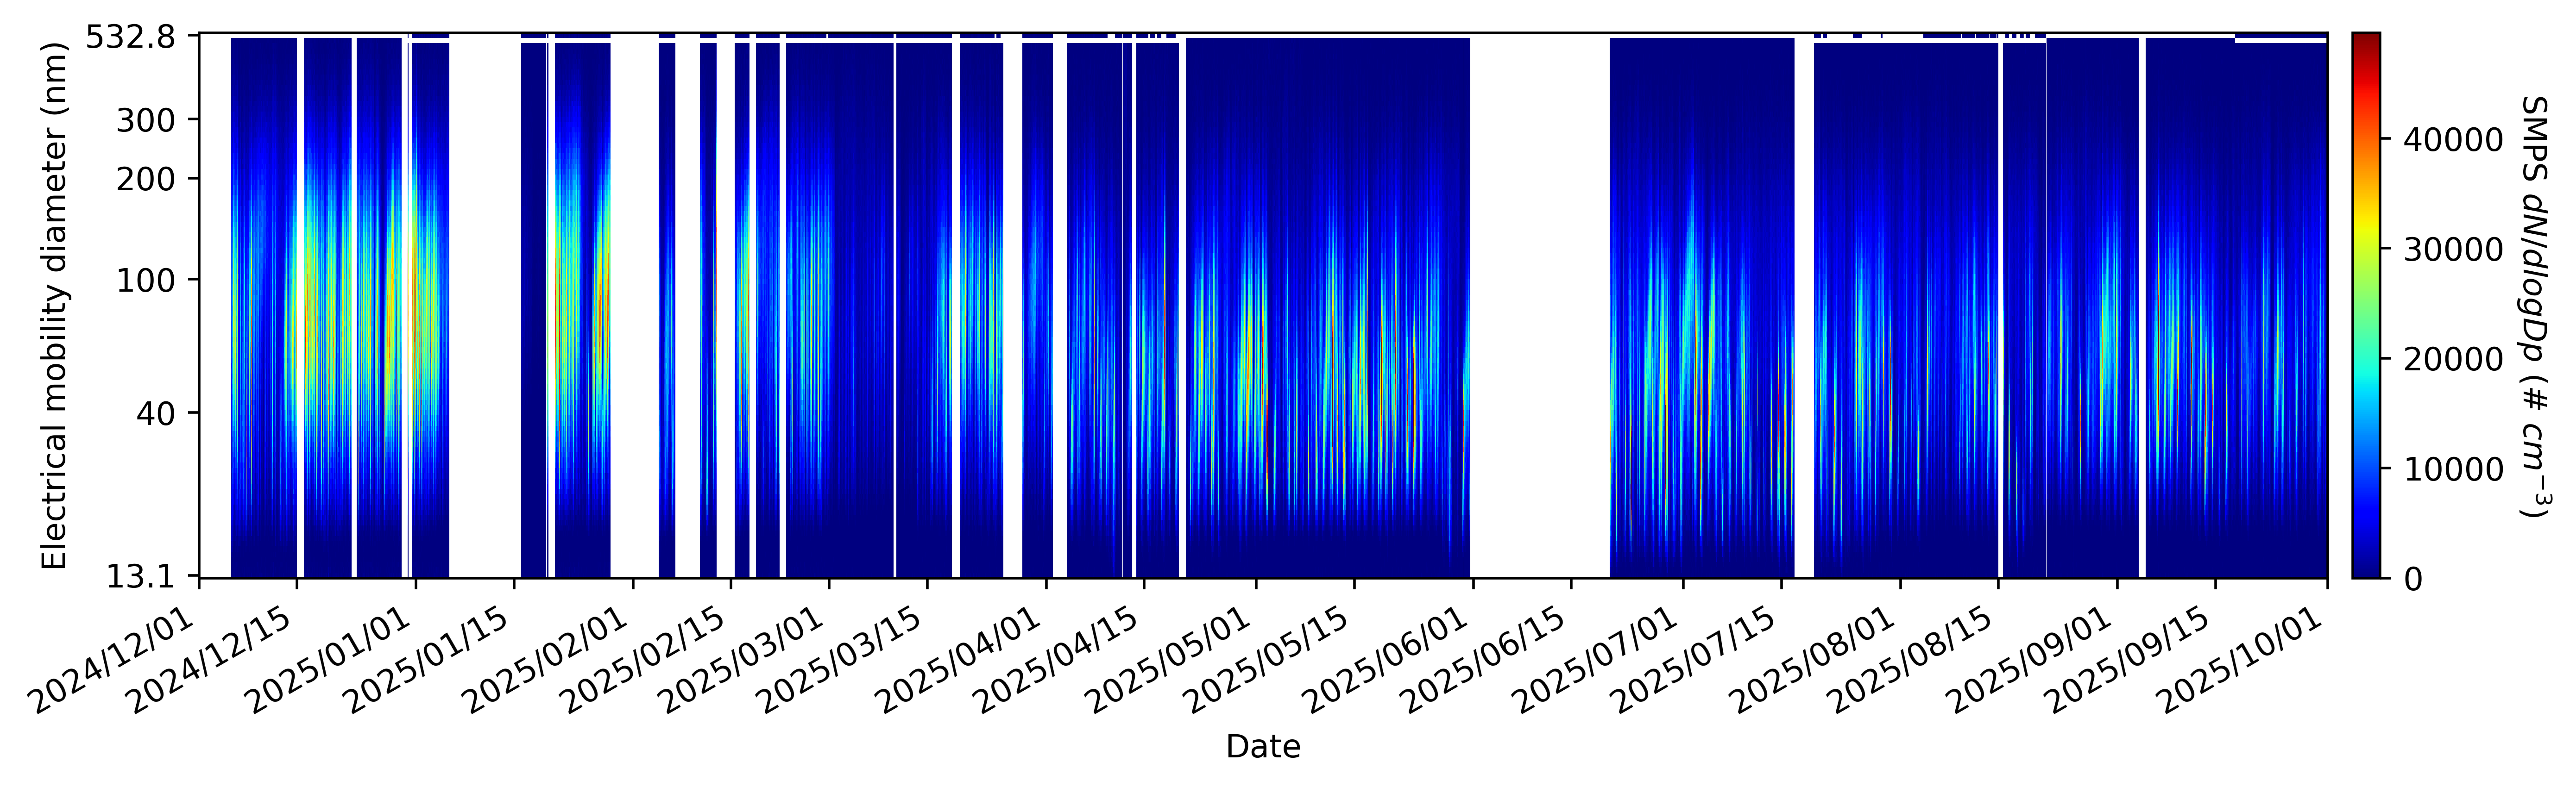

In [4]:
# 4. 绘制时间序列图

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FixedLocator, NullLocator

upper_bound = 99.9 # 颜色上限的分位数
# --- 0) 准备：确保 t 是 datetime，Dp 是 float array，dN 是 (bin, time) ---
t = m.index

BIN_COLS.sort(key=lambda x: float(x))
Dp = np.array(BIN_COLS).astype(float)# unit: nm

dN = m.to_numpy().T  # (bin, time)

# 1) 计算 x 轴边界（pcolormesh 需要 edges）
t_num = mdates.date2num(pd.to_datetime(t).to_numpy())
dt = np.median(np.diff(t_num))
x_edges = np.r_[t_num[0] - 0.5*dt,
                0.5*(t_num[:-1] + t_num[1:]),
                t_num[-1] + 0.5*dt]

# 2) 计算 y 轴边界（用相邻几何均值当 bin 边界；首尾做外推）
y_edges = np.empty(len(Dp)+1)
y_edges[1:-1] = np.sqrt(Dp[:-1] * Dp[1:])
y_edges[0] = Dp[0]**2 / y_edges[1]
y_edges[-1] = Dp[-1]**2 / y_edges[-2]

#print(len(x_edges), len(y_edges), dN.shape[1]+1, dN.shape[0]+1)  # 检查维度是否匹配

# 3) 颜色：线性 dN（<0 设为 NaN，用于显示缺测/无效）
Z = np.where(dN >= 0, dN, np.nan)

vmin = 0
vmax = np.nanpercentile(Z, upper_bound)
Z = np.ma.masked_invalid(Z) # 这一行需要放在 vmax (分位数)计算之后
# 4) 作图
fig, ax = plt.subplots(figsize=(12, 3.5), dpi=500)

cmap = plt.colormaps["jet"].copy()
cmap.set_bad("white")

pcm = ax.pcolormesh(x_edges, y_edges, Z, shading="auto",
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax
                    )

ax.set_yscale("log")
ax.set_ylabel("Electrical mobility diameter (nm)")
ax.set_xlabel("Date")

# y 刻度
yticks = [13.1, 40, 100, 200, 300, 532.8]
ax.yaxis.set_major_locator(FixedLocator(yticks))
ax.yaxis.set_minor_locator(NullLocator())
ax.yaxis.set_major_formatter(lambda v, pos: f"{v:g}")
ax.set_ylim(y_edges[0], y_edges[-1])

# x 轴
ax.set_xlim(pd.Timestamp("2024-12-01"), pd.Timestamp("2025-10-01"))
ax.xaxis.set_major_locator(mdates.DayLocator(bymonthday=[1, 15]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y/%m/%d"))
fig.autofmt_xdate()  # 自动旋转日期标签

# colorbar
cbar = fig.colorbar(pcm, ax=ax, pad=0.01)
cbar.set_label("SMPS $dN/dlogDp$ (# $cm^{-3}$)", rotation=270, labelpad=15)
#cbar.set_ticks([0, 0.5, 1, 1.5, 2, 2.5])

plt.tight_layout()
plt.show()
#plt.savefig(r"C:\Users\admin\Desktop\temp\3.png", dpi=500)

In [5]:
# 找出特定时间段内最大值所在的时间和粒径

# 假设我们只关心某个特定时间段内的最大值
start_time = pd.Timestamp('2025-02-12 00:00')
end_time = pd.Timestamp('2025-02-13 00:00')

# 创建时间掩码
time_mask = (t >= start_time) & (t <= end_time)

# 将 Z 和时间掩码对齐
Z_filtered = np.where(time_mask, Z, np.nan)

# 找出过滤后数据中的最大值位置
max_idx = np.unravel_index(np.nanargmax(Z_filtered), Z_filtered.shape)
max_time = t[max_idx[1]]
max_dp = Dp[max_idx[0]]
print(f"最大值位置：时间 = {max_time}, 粒径 = {max_dp} nm, dN/dlogDp = {Z[max_idx]}")

最大值位置：时间 = 2025-02-12 21:57:56, 粒径 = 145.9 nm, dN/dlogDp = 63995.677


### 24/12/15-24/12/16 

仪器问题的导致数据问题

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

win = m.loc["2024-12-14 18:00":"2024-12-16 00:00"]
fig, ax = plt.subplots(dpi=160)
for col in [' 98.2', '201.7', '495.8']:
    y = win[col]
    logy = np.log10(y.where(y > 0))
    ax.plot(win.index, logy, marker=".", linewidth=0.8, label=col+" nm")
ax.axvline(pd.Timestamp("2024-12-15"), linestyle="--")
ax.legend()
ax.set_ylabel("$log_{10}(dN)$")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%y/%m/%d %H:%M"))
fig.autofmt_xdate()# 自动旋转日期标签
#plt.tight_layout()
plt.show()


### 24/12/22-24/12/23 数据异常

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

win = m.loc["2024-12-22 19:00":"2024-12-23 12:00"]
fig, ax = plt.subplots(dpi=160)
for col in [' 98.2', '201.7', '495.8']:
    y = win[col]
    logy = np.log10(y.where(y > 0))
    ax.plot(win.index, logy, marker=".", linewidth=0.8, label=col+" nm")
#ax.axvline(pd.Timestamp("2024-12-15"), linestyle="--")
ax.legend()
ax.set_ylabel("$log_{10}(dN)$")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%y/%m/%d %H:%M"))
fig.autofmt_xdate()# 自动旋转日期标签
#plt.tight_layout()
plt.show()


### 25/03/10-25/03/11 数据

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

win = m.loc["2025-03-10 04:00":"2025-03-10 14:00"]
fig, ax = plt.subplots(dpi=160)
for col in [' 98.2', '201.7', '495.8']:
    y = win[col]
    logy = np.log10(y.where(y > 0))
    ax.plot(win.index, logy, marker=".", linewidth=0.8, label=col+" nm")
ax.axvline(pd.Timestamp("2025-03-10"), linestyle="--")
ax.legend()
ax.set_ylabel("$log_{10}(dN)$")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%y/%m/%d %H:%M"))
ax.set_xlim(pd.Timestamp("2025-03-10 00:00"), pd.Timestamp("2025-03-11 00:00"))
fig.autofmt_xdate()# 自动旋转日期标签
plt.show()
